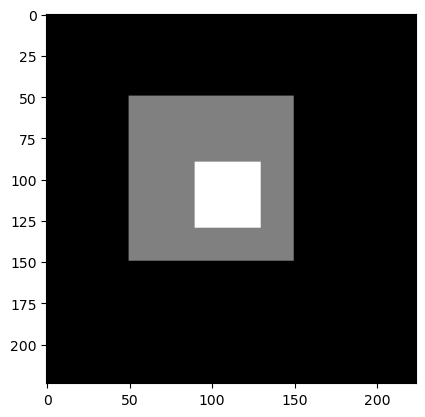

In [9]:
import torch
import matplotlib.pyplot as plt

img = torch.zeros((1, 1, 224, 224), dtype=torch.float32)
img[:, :, 50:150, 50:150] = 0.5
img[:, :, 90:130, 90:130] = 1.0
plt.imshow(img[0, 0].numpy(), cmap='gray')
plt.show()

In [10]:
from my_models_mae import mae_vit_base_patch16

model = mae_vit_base_patch16(
    norm_pix_loss=False,
    in_chans=1,
    loss_on_all_patches=False,
    pos_encode_w=1,
)
model

MaskedAutoencoderViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (blocks): ModuleList(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
    (1): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_feature

In [11]:
import torch.nn as nn
from timm.models.vision_transformer import PatchEmbed, Attention, Mlp


def init_weights(m):
    # # m.weight.data.fill_(1.0)
    # # m.bias.data.fill_(0.0)
    # if isinstance(m, PatchEmbed):
    #     nn.init.constant_(m.proj.weight, 1.0)
    #     nn.init.constant_(m.proj.bias, 0.0)
    # elif isinstance(m, nn.Dropout) or isinstance(m, nn.Identity) or isinstance(m, nn.GELU):
    #     pass
    # elif isinstance(m, Attention):
    #     nn.init.constant_(m.qkv.weight, 1.0)
    #     nn.init.constant_(m.qkv.bias, 0.0)
    #     nn.init.constant_(m.proj.weight, 1.0)
    #     nn.init.constant_(m.proj.bias, 0.0)
    # elif isinstance(m, Mlp):
    #     nn.init.constant_(m.fc1.weight, 1.0)
    #     nn.init.constant_(m.fc1.bias, 0.0)
    #     nn.init.constant_(m.fc2.weight, 1.0)
    #     nn.init.constant_(m.fc2.bias, 0.0)
    # else:
    #     nn.init.constant_(m.weight, 1.0)
    #     nn.init.constant_(m.bias, 0.0)
    if hasattr(m, 'weight'):
        nn.init.constant_(m.weight, 0.1)
    if hasattr(m, 'bias'):
        nn.init.constant_(m.bias, 0.0)

model.apply(init_weights)
nn.init.constant_(model.cls_token, 1.0)
nn.init.constant_(model.mask_token, 1.0)

Parameter containing:
tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 

In [12]:
def fixed_random_masking(x, mask_ratio):
        ids_keep = torch.tensor(
            [
                [
                    141,
                    86,
                    90,
                    10,
                    12,
                    22,
                    46,
                    54,
                    84,
                    190,
                    112,
                    15,
                    64,
                    94,
                    70,
                    19,
                    162,
                    67,
                    7,
                    149,
                    28,
                    2,
                    80,
                    154,
                    18,
                    69,
                    173,
                    182,
                    106,
                    89,
                    31,
                    140,
                    111,
                    134,
                    37,
                    49,
                    131,
                    82,
                    158,
                    110,
                    142,
                    32,
                    153,
                    50,
                    3,
                    91,
                    180,
                    36,
                    125,
                ]
            ],
            dtype=torch.long,
        )
        ids_mask = torch.tensor(
            [
                [
                    48,
                    116,
                    176,
                    187,
                    44,
                    137,
                    127,
                    39,
                    68,
                    132,
                    63,
                    66,
                    122,
                    129,
                    40,
                    102,
                    155,
                    161,
                    8,
                    59,
                    1,
                    133,
                    4,
                    181,
                    115,
                    148,
                    138,
                    136,
                    65,
                    92,
                    25,
                    41,
                    9,
                    192,
                    147,
                    163,
                    47,
                    139,
                    29,
                    194,
                    42,
                    99,
                    169,
                    16,
                    71,
                    103,
                    13,
                    166,
                    74,
                    56,
                    97,
                    188,
                    195,
                    5,
                    77,
                    113,
                    183,
                    107,
                    175,
                    118,
                    157,
                    120,
                    172,
                    85,
                    35,
                    146,
                    45,
                    78,
                    178,
                    128,
                    14,
                    109,
                    186,
                    160,
                    159,
                    52,
                    104,
                    189,
                    34,
                    174,
                    193,
                    151,
                    43,
                    21,
                    191,
                    0,
                    121,
                    73,
                    17,
                    124,
                    135,
                    51,
                    27,
                    98,
                    26,
                    143,
                    165,
                    87,
                    72,
                    144,
                    24,
                    76,
                    83,
                    100,
                    184,
                    145,
                    177,
                    88,
                    23,
                    20,
                    61,
                    130,
                    11,
                    55,
                    75,
                    152,
                    95,
                    108,
                    60,
                    53,
                    168,
                    123,
                    171,
                    179,
                    58,
                    150,
                    105,
                    170,
                    57,
                    167,
                    6,
                    38,
                    164,
                    126,
                    33,
                    93,
                    119,
                    30,
                    101,
                    156,
                    96,
                    117,
                    81,
                    79,
                    114,
                    62,
                    185,
                ]
            ],
            dtype=torch.long,
        )
        mask = torch.tensor(
            [
                [
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    0.0,
                    1.0,
                    0.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    0.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                    1.0,
                ]
            ],
            dtype=torch.long,
        )
        ids_restore = torch.tensor(
            [
                [
                    134,
                    69,
                    21,
                    44,
                    71,
                    102,
                    179,
                    18,
                    67,
                    81,
                    3,
                    161,
                    4,
                    95,
                    119,
                    11,
                    92,
                    137,
                    24,
                    15,
                    158,
                    132,
                    5,
                    157,
                    149,
                    79,
                    143,
                    141,
                    20,
                    87,
                    186,
                    30,
                    41,
                    183,
                    127,
                    113,
                    47,
                    34,
                    180,
                    56,
                    63,
                    80,
                    89,
                    131,
                    53,
                    115,
                    6,
                    85,
                    49,
                    35,
                    43,
                    140,
                    124,
                    168,
                    7,
                    162,
                    98,
                    177,
                    173,
                    68,
                    167,
                    159,
                    194,
                    59,
                    12,
                    77,
                    60,
                    17,
                    57,
                    25,
                    14,
                    93,
                    147,
                    136,
                    97,
                    163,
                    150,
                    103,
                    116,
                    192,
                    22,
                    191,
                    37,
                    151,
                    8,
                    112,
                    1,
                    146,
                    156,
                    29,
                    2,
                    45,
                    78,
                    184,
                    13,
                    165,
                    189,
                    99,
                    142,
                    90,
                    152,
                    187,
                    64,
                    94,
                    125,
                    175,
                    28,
                    106,
                    166,
                    120,
                    39,
                    32,
                    10,
                    104,
                    193,
                    73,
                    50,
                    190,
                    108,
                    185,
                    110,
                    135,
                    61,
                    170,
                    138,
                    48,
                    182,
                    55,
                    118,
                    62,
                    160,
                    36,
                    58,
                    70,
                    33,
                    139,
                    76,
                    54,
                    75,
                    86,
                    31,
                    0,
                    40,
                    144,
                    148,
                    154,
                    114,
                    83,
                    74,
                    19,
                    174,
                    130,
                    164,
                    42,
                    23,
                    65,
                    188,
                    109,
                    38,
                    123,
                    122,
                    66,
                    16,
                    84,
                    181,
                    145,
                    96,
                    178,
                    169,
                    91,
                    176,
                    171,
                    111,
                    26,
                    128,
                    107,
                    51,
                    155,
                    117,
                    172,
                    46,
                    72,
                    27,
                    105,
                    153,
                    195,
                    121,
                    52,
                    100,
                    126,
                    9,
                    133,
                    82,
                    129,
                    88,
                    101,
                ]
            ],
            dtype=torch.long,
        )
        N, L, D = x.shape  # batch, length, dim
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        mask = torch.ones([N, L], device=x.device)
        mask[:, : ids_keep.shape[1]] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        return x_masked, mask, ids_restore

In [13]:
model.random_masking = fixed_random_masking

In [14]:
loss, pred, mask = model(img, mask_ratio=0.75)
print(loss)

tensor(0.0713, grad_fn=<DivBackward0>)
